#📌 Extracción

## Carga Datos

In [2]:
import pandas as pd
import numpy as np

In [3]:
!pip install requests
import requests
import json

In [4]:
urlDatos = requests.get('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json')
urlDatos

<Response [200]>

In [5]:
resultadoDatos = urlDatos.json()
resultadoDatos

[{'customerID': '0002-ORFBO',
  'Churn': 'No',
  'customer': {'gender': 'Female',
   'SeniorCitizen': 0,
   'Partner': 'Yes',
   'Dependents': 'Yes',
   'tenure': 9},
  'phone': {'PhoneService': 'Yes', 'MultipleLines': 'No'},
  'internet': {'InternetService': 'DSL',
   'OnlineSecurity': 'No',
   'OnlineBackup': 'Yes',
   'DeviceProtection': 'No',
   'TechSupport': 'Yes',
   'StreamingTV': 'Yes',
   'StreamingMovies': 'No'},
  'account': {'Contract': 'One year',
   'PaperlessBilling': 'Yes',
   'PaymentMethod': 'Mailed check',
   'Charges': {'Monthly': 65.6, 'Total': '593.3'}}},
 {'customerID': '0003-MKNFE',
  'Churn': 'No',
  'customer': {'gender': 'Male',
   'SeniorCitizen': 0,
   'Partner': 'No',
   'Dependents': 'No',
   'tenure': 9},
  'phone': {'PhoneService': 'Yes', 'MultipleLines': 'Yes'},
  'internet': {'InternetService': 'DSL',
   'OnlineSecurity': 'No',
   'OnlineBackup': 'No',
   'DeviceProtection': 'No',
   'TechSupport': 'No',
   'StreamingTV': 'No',
   'StreamingMovies': 

## Revisión Datos

In [6]:
datos = pd.DataFrame(resultadoDatos)
datos.head(5)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## Normalizacion Datos

In [7]:
df_datoCustomer_normalizado = pd.json_normalize(datos['customer'])
df_datoCustomer_normalizado.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure
1545,Female,0,Yes,Yes,26
5583,Male,1,No,No,66
682,Female,0,No,No,1
5709,Male,0,Yes,No,27
4863,Male,0,Yes,Yes,49


In [8]:
df_datoPhone_normalizado = pd.json_normalize(datos['phone'])
df_datoPhone_normalizado.sample(5)

,PhoneService,MultipleLines
306,Yes,Yes
252,No,No phone service
956,Yes,No
5147,Yes,No
6316,Yes,Yes


In [9]:
df_datoInternet_normalizado = pd.json_normalize(datos['internet'])
df_datoInternet_normalizado.sample(5)

,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
3930,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
4087,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
1082,DSL,Yes,No,No,No,No,No
311,Fiber optic,No,Yes,No,No,Yes,Yes
2169,DSL,No,Yes,Yes,No,No,No


In [10]:
df_datoAccount_normalizado = pd.json_normalize(datos['account'])
df_datoAccount_normalizado.sample(5)

,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
2926,Month-to-month,No,Bank transfer (automatic),94.60,5025.8
1222,Month-to-month,No,Credit card (automatic),75.35,75.35
2106,Month-to-month,Yes,Credit card (automatic),85.30,781.4
5534,One year,Yes,Credit card (automatic),70.15,4224.7
2853,One year,No,Bank transfer (automatic),65.20,4543.15


## Union Dataframes Normalizados

In [11]:
normalized_dataframes = [
    df_datoCustomer_normalizado,
    df_datoPhone_normalizado,
    df_datoInternet_normalizado,
    df_datoAccount_normalizado
]
normalized_dataframes


[      gender  SeniorCitizen Partner Dependents  tenure
 0     Female              0     Yes        Yes       9
 1       Male              0      No         No       9
 2       Male              0      No         No       4
 3       Male              1     Yes         No      13
 4     Female              1     Yes         No       3
 ...      ...            ...     ...        ...     ...
 7262  Female              0      No         No      13
 7263    Male              0     Yes         No      22
 7264    Male              0      No         No       2
 7265    Male              0     Yes        Yes      67
 7266    Male              0     Yes        Yes      63
 
 [7267 rows x 5 columns],
      PhoneService     MultipleLines
 0             Yes                No
 1             Yes               Yes
 2             Yes                No
 3             Yes                No
 4             Yes                No
 ...           ...               ...
 7262          Yes                No
 726

In [12]:
df_datos_v1 = pd.concat(
    [datos[['customerID', 'Churn']]] + normalized_dataframes,
    axis=1
)

df_datos_v1.head(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

## Revision Datos

### Revision Datos tipo object

In [13]:
for col in df_datos_v1.select_dtypes(include='object').drop(columns=['customerID']).columns:
    print(f"\n--- {col} ---")
    print(df_datos_v1[col].unique())



--- Churn ---
['No' 'Yes' '']

--- gender ---
['Female' 'Male']

--- Partner ---
['Yes' 'No']

--- Dependents ---
['Yes' 'No']

--- PhoneService ---
['Yes' 'No']

--- MultipleLines ---
['No' 'Yes' 'No phone service']

--- InternetService ---
['DSL' 'Fiber optic' 'No']

--- OnlineSecurity ---
['No' 'Yes' 'No internet service']

--- OnlineBackup ---
['Yes' 'No' 'No internet service']

--- DeviceProtection ---
['No' 'Yes' 'No internet service']

--- TechSupport ---
['Yes' 'No' 'No internet service']

--- StreamingTV ---
['Yes' 'No' 'No internet service']

--- StreamingMovies ---
['No' 'Yes' 'No internet service']

--- Contract ---
['One year' 'Month-to-month' 'Two year']

--- PaperlessBilling ---
['Yes' 'No']

--- PaymentMethod ---
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

--- Charges.Total ---
['593.3' '542.4' '280.85' ... '742.9' '4627.65' '3707.6']


#### Coreccion Datos tipo object

In [14]:
df_datos_v1['Churn'] = df_datos_v1['Churn'].replace('', 'Unknown')

In [15]:
for col in df_datos_v1.select_dtypes(include='object').drop(columns=['customerID']).columns:
    print(f"\n--- {col} ---")
    print(df_datos_v1[col].unique())



--- Churn ---
['No' 'Yes' 'Unknown']

--- gender ---
['Female' 'Male']

--- Partner ---
['Yes' 'No']

--- Dependents ---
['Yes' 'No']

--- PhoneService ---
['Yes' 'No']

--- MultipleLines ---
['No' 'Yes' 'No phone service']

--- InternetService ---
['DSL' 'Fiber optic' 'No']

--- OnlineSecurity ---
['No' 'Yes' 'No internet service']

--- OnlineBackup ---
['Yes' 'No' 'No internet service']

--- DeviceProtection ---
['No' 'Yes' 'No internet service']

--- TechSupport ---
['Yes' 'No' 'No internet service']

--- StreamingTV ---
['Yes' 'No' 'No internet service']

--- StreamingMovies ---
['No' 'Yes' 'No internet service']

--- Contract ---
['One year' 'Month-to-month' 'Two year']

--- PaperlessBilling ---
['Yes' 'No']

--- PaymentMethod ---
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

--- Charges.Total ---
['593.3' '542.4' '280.85' ... '742.9' '4627.65' '3707.6']


### Revision Datos tipos numericos

In [16]:
df_datos_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [17]:
df_datos_v1.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


#### Correccion de datos tipo numericos

In [18]:
df_datos_v1['Charges.Total'] = (
    df_datos_v1['Charges.Total']
    .replace(r'^\s*$|^(?!\d+(\.\d+)?$).*$', None, regex=True)
    .astype('float64')
)


In [19]:
df_datos_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


#📊 Carga y análisis

## Info diccionario

#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

## Importacion modulos visualizacion datos

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
!pip install dataframe_image
import dataframe_image as dfi

## Calculo Estadisticas

In [69]:
resumen_stats = df_datos_v1[['tenure', 'Charges.Monthly', 'Charges.Total']].describe()
resumen_stats.index.name = 'Estadísticas'
resumen_stats


,tenure,Charges.Monthly,Charges.Total
Estadísticas,,,
count,7267.000000,7267.000000,7256.000000
mean,32.346498,64.720098,2280.634213
std,24.571773,30.129572,2268.632997
min,0.000000,18.250000,18.800000
25%,9.000000,35.425000,400.225000
50%,29.000000,70.300000,1391.000000
75%,55.000000,89.875000,3785.300000
max,72.000000,118.750000,8684.800000


In [70]:
estilo_para_exportar = resumen_stats.style.format("{:.2f}")
dfi.export(estilo_para_exportar, 'tabla_stats_descriptivas.png', table_conversion='matplotlib')

In [22]:
df_datos_v1['Churn'].unique()

array(['No', 'Yes', 'Unknown'], dtype=object)

In [23]:
AbandonoClientes = pd.DataFrame(df_datos_v1['Churn'].value_counts())
AbandonoClientes.columns = ['Cantidad']
AbandonoClientes.index.name = 'Churn'

AbandonoClientes

,Cantidad
Churn,
No,5174
Yes,1869
Unknown,224


In [24]:
porcentajeChurn = AbandonoClientes['Cantidad'].to_numpy() / AbandonoClientes['Cantidad'].sum() * 100
porcentajeChurn

array([71.19856887, 25.71900372,  3.08242741])

In [25]:
AbandonoClientes['Porcentaje'] = porcentajeChurn
AbandonoClientes

,Cantidad,Porcentaje
Churn,,
No,5174,71.198569
Yes,1869,25.719004
Unknown,224,3.082427


In [26]:
estilo_AbandonoClientes = AbandonoClientes.style
estilo_AbandonoClientes

,Cantidad,Porcentaje
Churn,,
No,5174,71.198569
Yes,1869,25.719004
Unknown,224,3.082427


In [46]:
encabezado = {
              'selector':'th',
              'props':'font-weight:bold,font-family:Arial,text-align:rigth,background-color:white'
}

celdas = {
              'selector':'td',
              'props':'background-color:white'
}

estilo_AbandonoClientes.set_table_styles([encabezado,celdas])

,Cantidad,Porcentaje
Churn,,
No,5174,71.20 %
Yes,1869,25.72 %
Unknown,224,3.08 %


In [50]:
estilo = estilo_AbandonoClientes.format({'Porcentaje':'{:.2f} %'})
dfi.export(estilo, 'tabla_abandono.png', table_conversion='matplotlib')

ERROR	Property: Invalid value for "CSS Fonts Module Level 3 @font-face properties/CSS Level 2.1" property: bold, font-family [3:3: font-weight]
ERROR:CSSUTILS:Property: Invalid value for "CSS Fonts Module Level 3 @font-face properties/CSS Level 2.1" property: bold, font-family [3:3: font-weight]
ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #9cd3bb 71.2%, transparent 71.2%) [10:3: background]
ERROR:CSSUTILS:Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #9cd3bb 71.2%, transparent 71.2%) [10:3: background]
ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #9cd3bb 71.2%, transparent 71.2%) [12:3: background]
ERROR:CSSUTILS:Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #9cd3bb 71.2%, transparent 71.2%) [12:3: background]
ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #9cd3bb 71.2%, transparent 71.2%) [14:3: background]
ERROR

## Visualizaciones

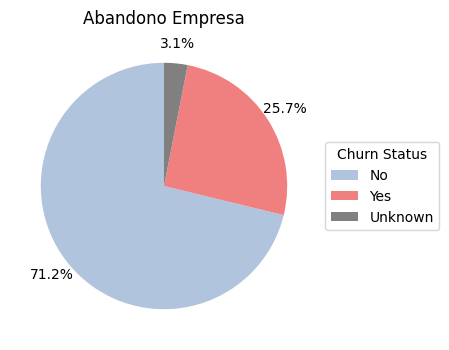

In [38]:
plt.figure(figsize=(4, 4))
colors = ['lightsteelblue', 'lightcoral', 'Gray']

plt.pie(
    AbandonoClientes['Porcentaje'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=1.16
)

plt.title('Abandono Empresa')
plt.legend(labels=AbandonoClientes.index, title="Churn Status", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.savefig('resumen_global_churn.png', dpi=300, bbox_inches='tight')

plt.show()

In [30]:
columnas_categoricas = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

COLORES_CHURN = {'No': '#2ecc71', 'Yes': '#e74c3c', 'Unknown': '#95a5a6'}
N_COLS = 3
N_ROWS = (len(columnas_categoricas) + N_COLS - 1) // N_COLS
ANCHO_FIG = 20
ALTO_FILA = 6

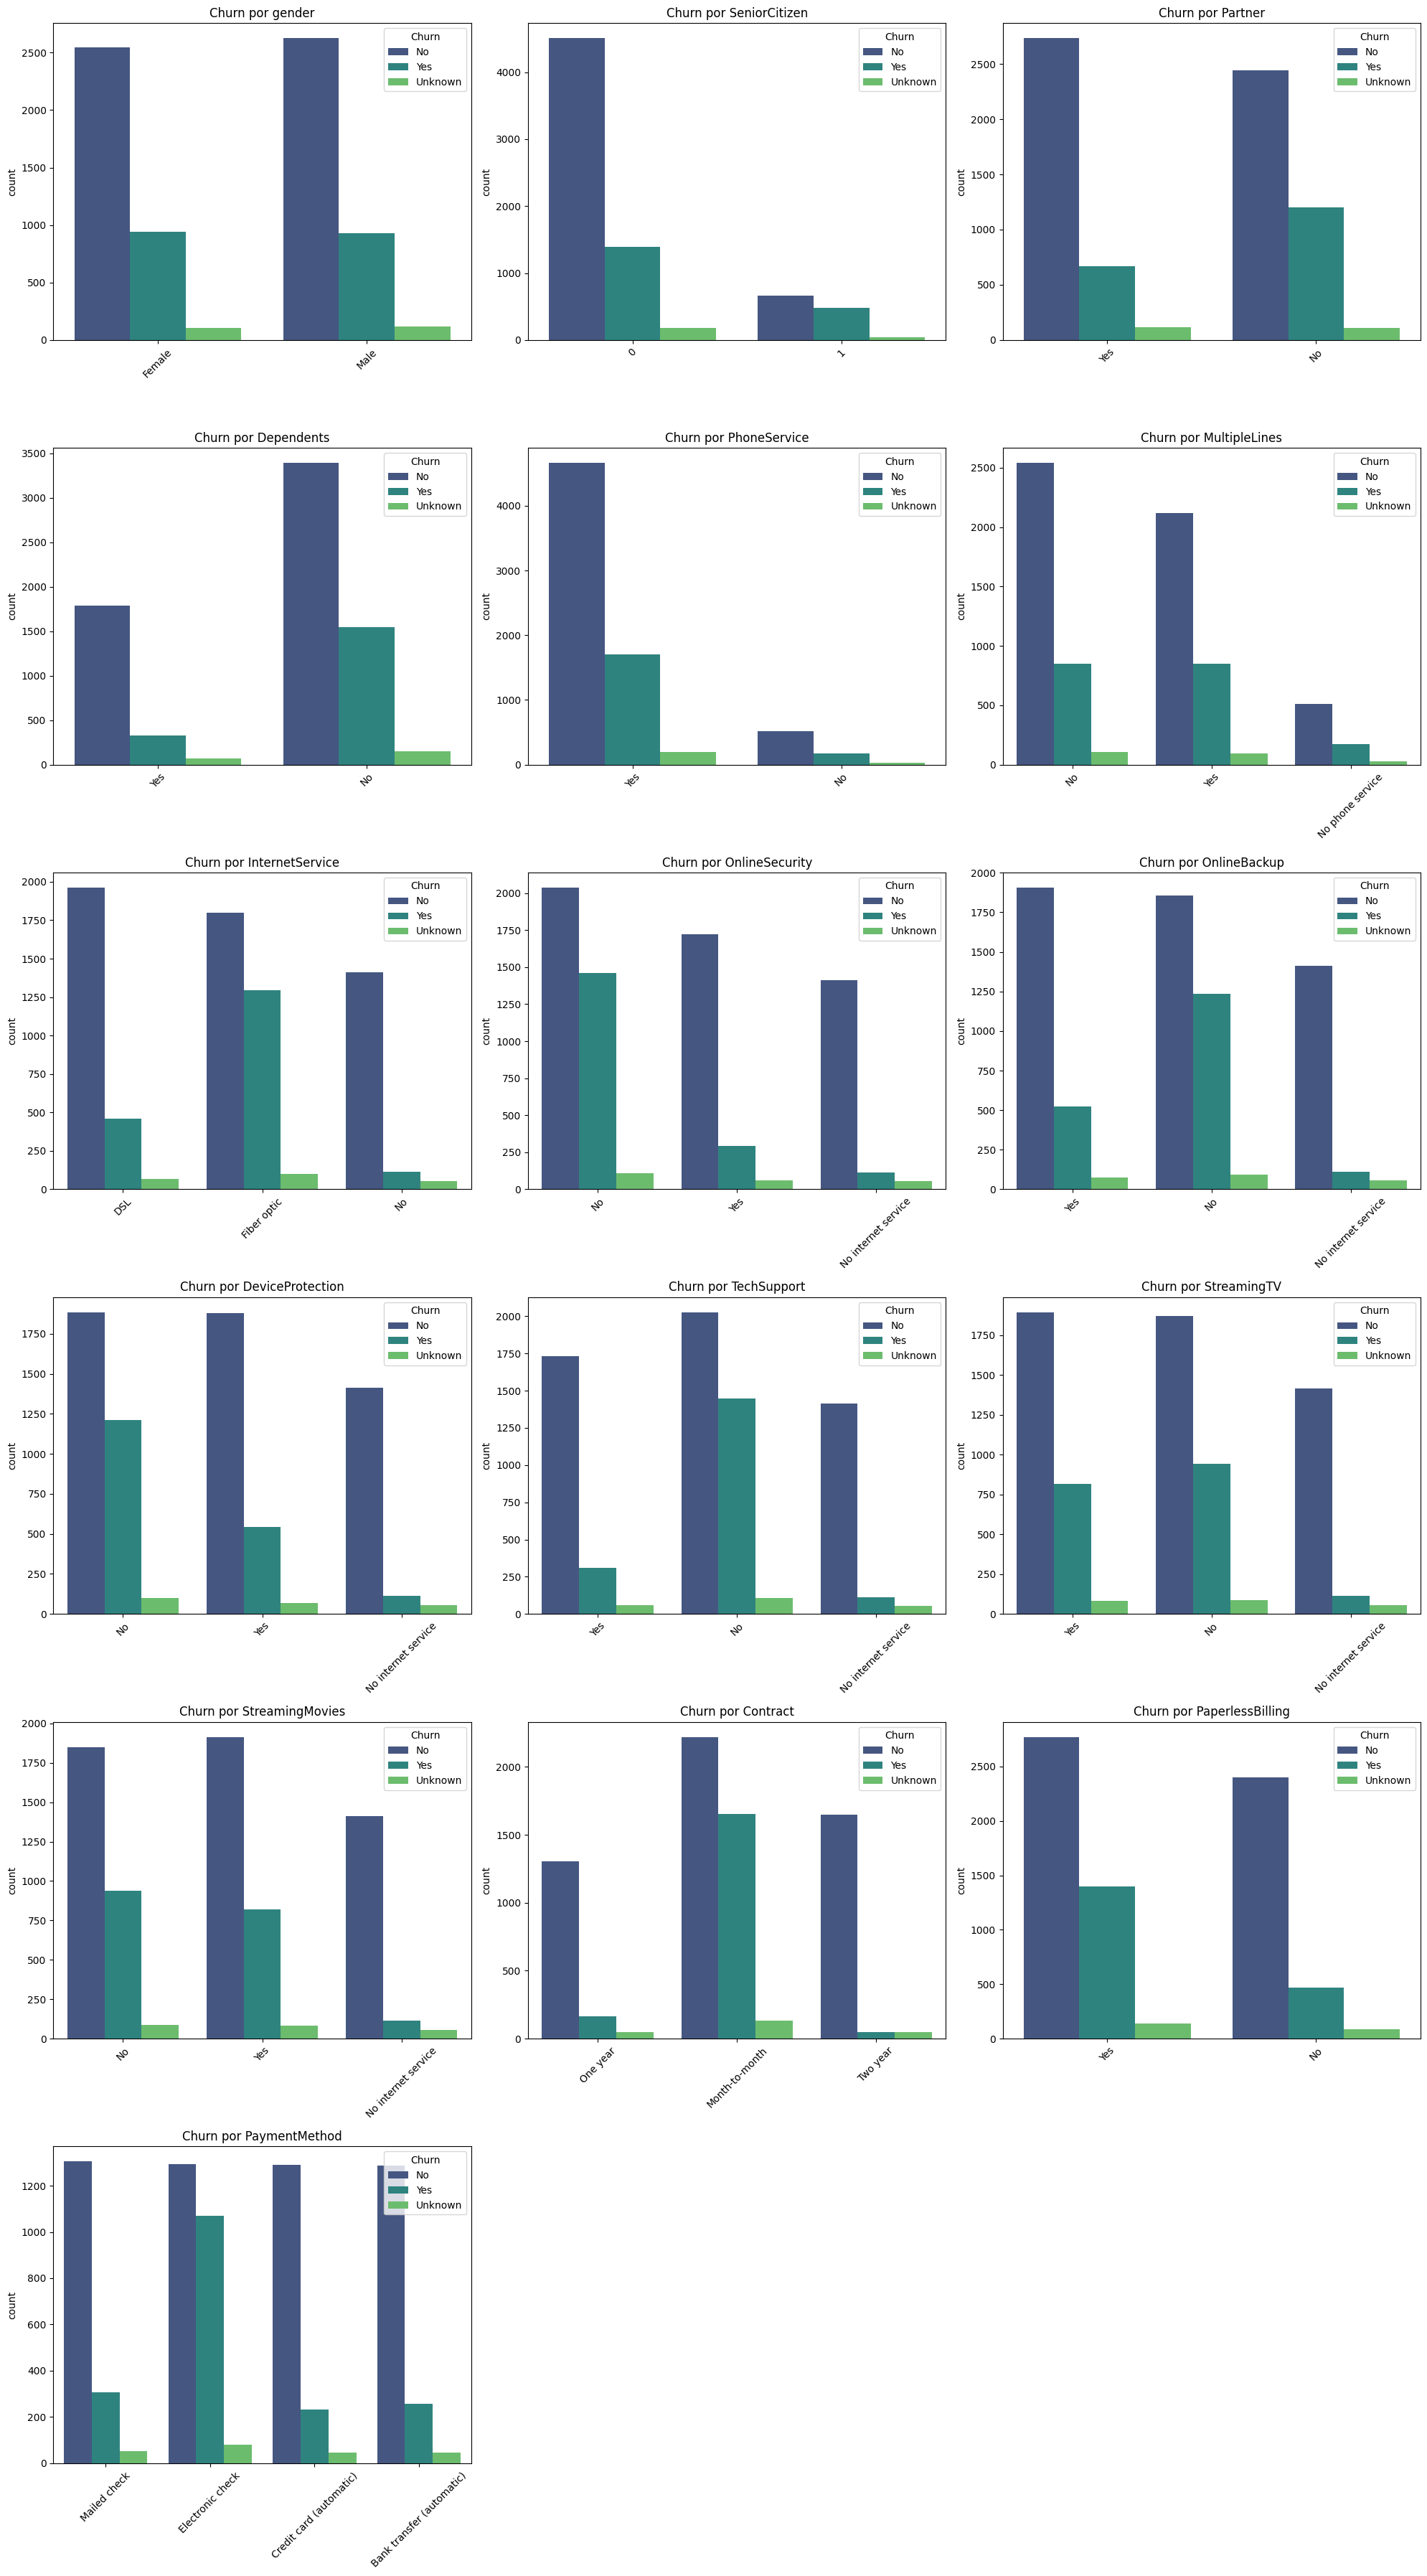

In [31]:
n_cols = 3
n_rows = (len(columnas_categoricas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, n_rows * 6))
axes = axes.flatten()

for i, col in enumerate(columnas_categoricas):
    sns.countplot(x=col, hue='Churn', data=df_datos_v1, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Churn por {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.savefig('analisis_categorico_churn.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

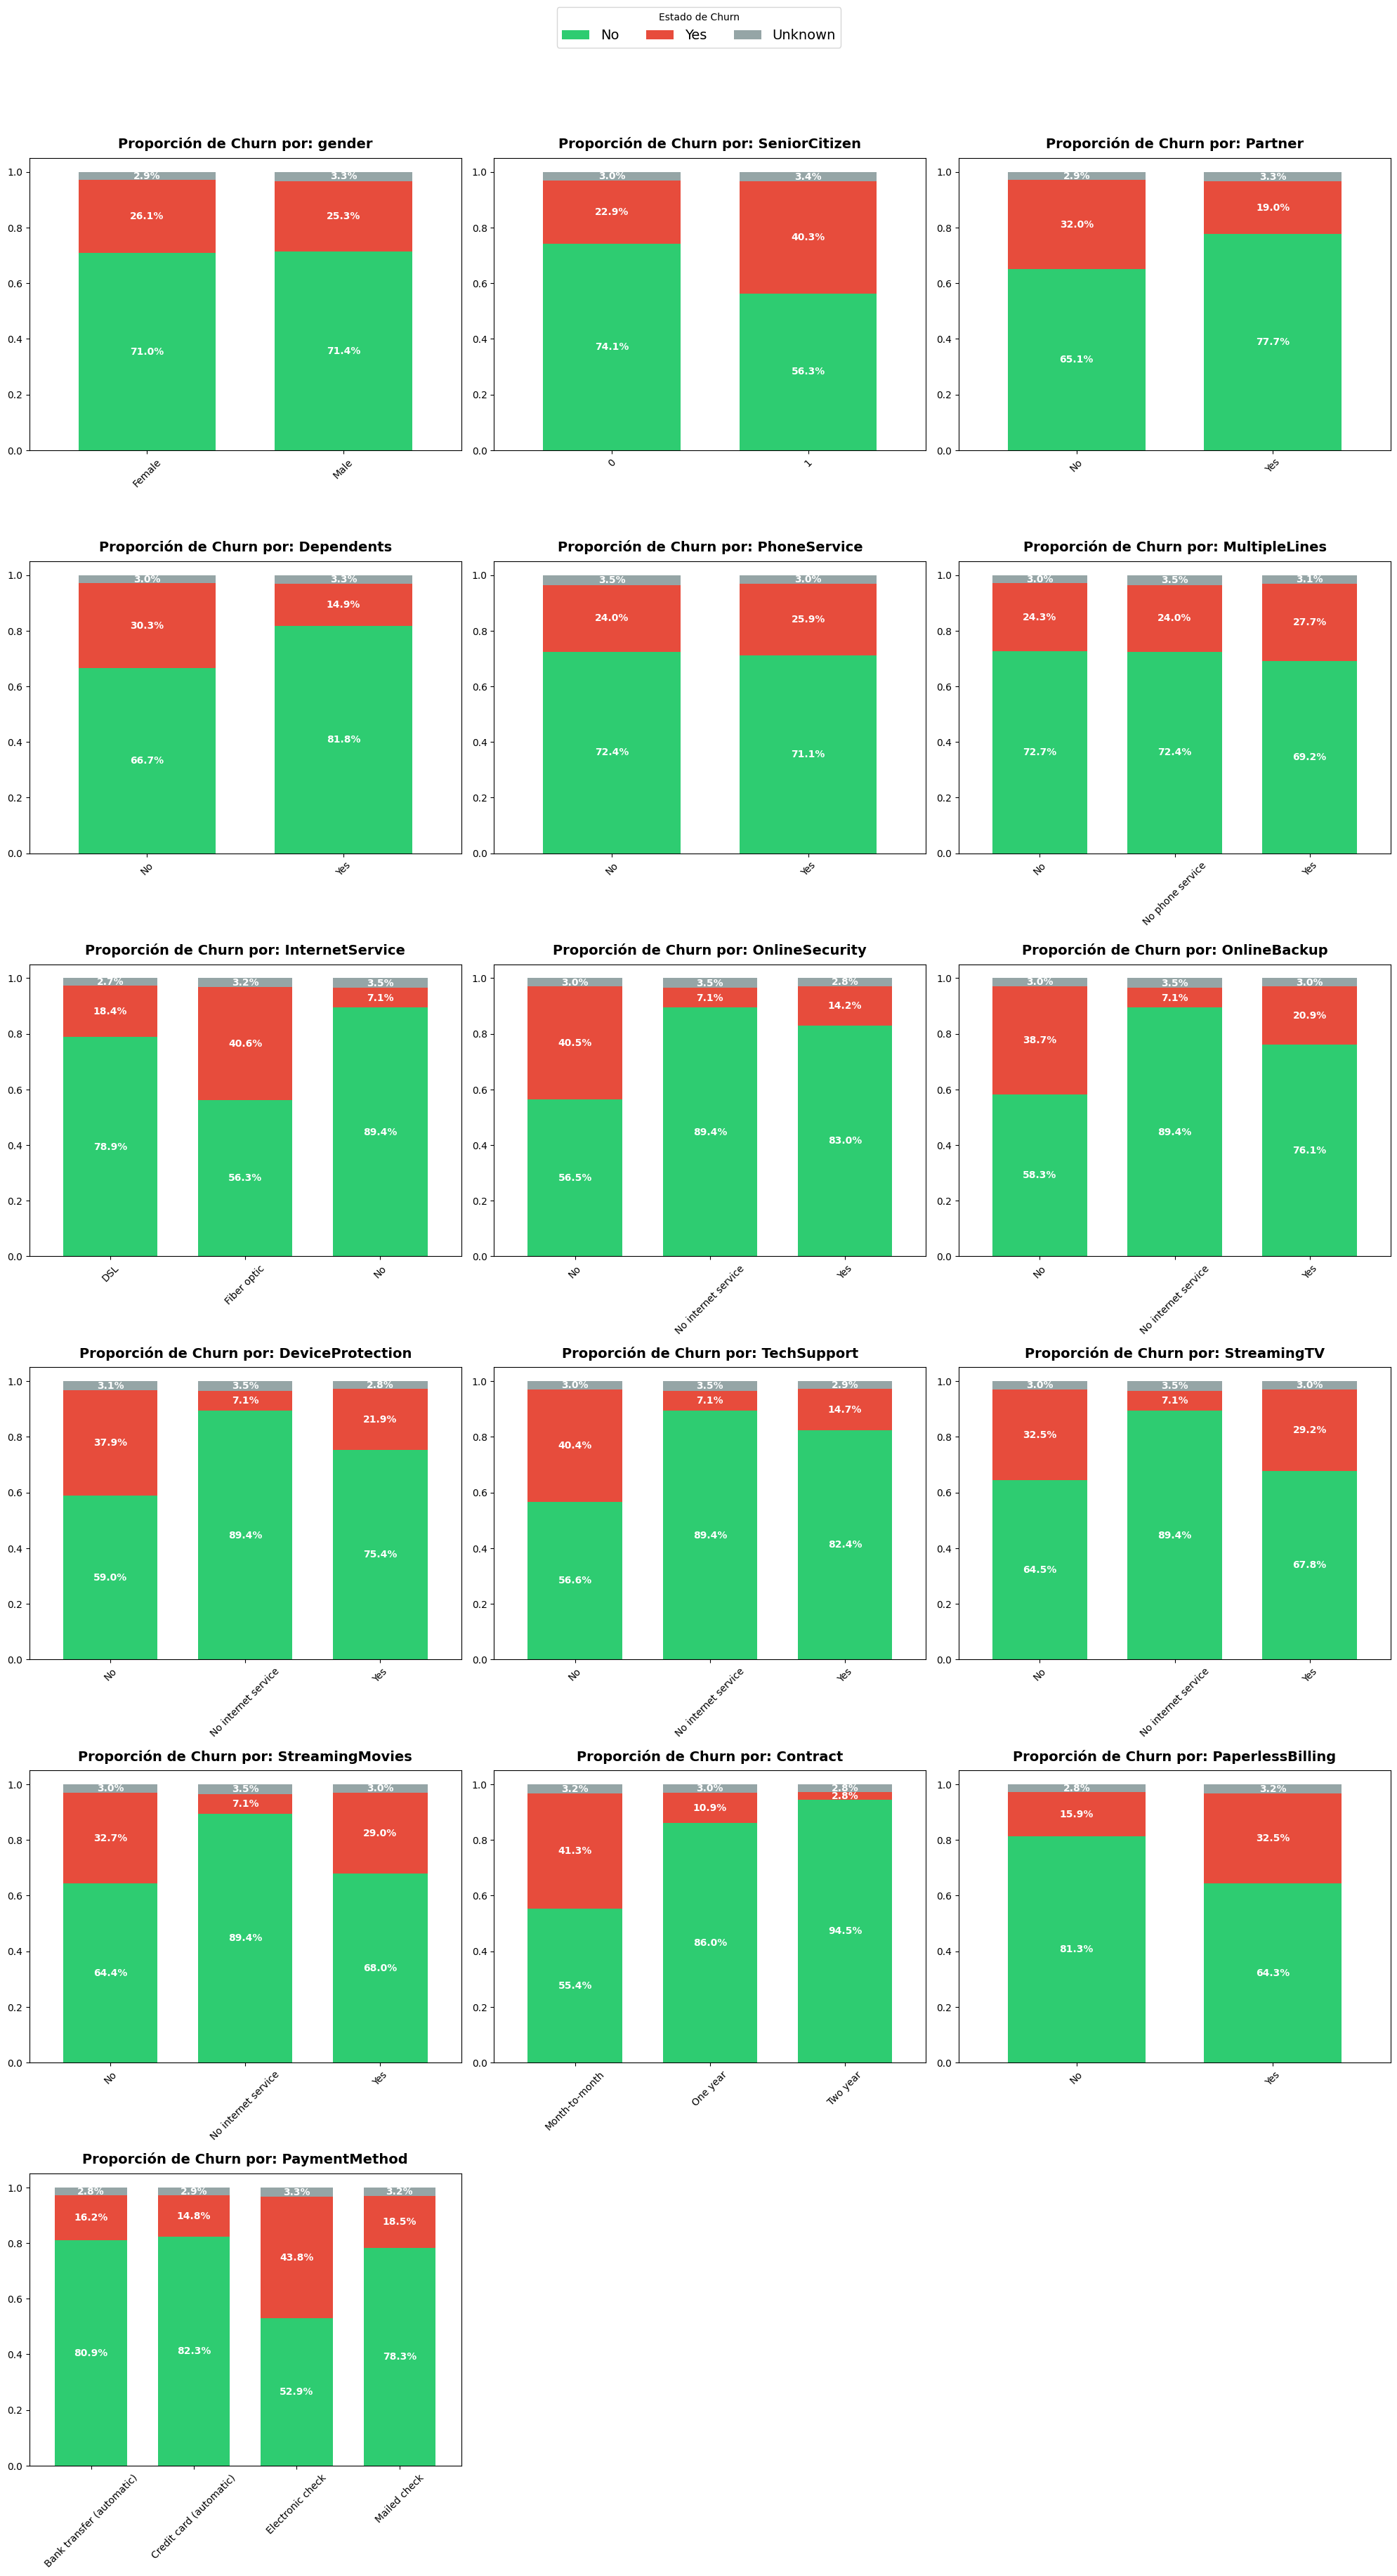

In [36]:
fig2, axes2 = plt.subplots(nrows=N_ROWS, ncols=N_COLS, figsize=(ANCHO_FIG, N_ROWS * ALTO_FILA))
axes2 = axes2.flatten()

for i, col in enumerate(columnas_categoricas):
    tabla = pd.crosstab(df_datos_v1[col], df_datos_v1['Churn'], normalize='index')


    orden_churn = [c for c in ['No', 'Yes', 'Unknown'] if c in tabla.columns]
    colores_actuales = [COLORES_CHURN[c] for c in orden_churn]

    tabla[orden_churn].plot(kind='bar', stacked=True, color=colores_actuales, ax=axes2[i], legend=False, width=0.7)

    axes2[i].set_title(f'Proporción de Churn por: {col}', fontsize=14, fontweight='bold', pad=10)
    axes2[i].set_xlabel('')
    axes2[i].tick_params(axis='x', rotation=45)


    for p in axes2[i].patches:
        h = p.get_height()
        if h > 0.02:
            axes2[i].text(p.get_x() + p.get_width()/2, p.get_y() + h/2,
                          f'{h*100:.1f}%', va='center', ha='center',
                          color='white', fontsize=10, fontweight='bold')


for j in range(i + 1, len(axes2)): fig2.delaxes(axes2[j])

handles, labels = axes2[0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='upper center', ncol=3,
            title="Estado de Churn", bbox_to_anchor=(0.5, 1.02), fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig('proporciones_categoricas_churn.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
COLORES_CHURN = {'No': '#2ecc71', 'Yes': '#e74c3c', 'Unknown': '#95a5a6'}
columnas_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total']
N_COLS_NUM = 3
N_ROWS_NUM = 1

/tmp/ipykernel_406/1739110520.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df_datos_v1, ax=axes[i],
/tmp/ipykernel_406/1739110520.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df_datos_v1, ax=axes[i],


Mediana de tenure: No=38.0, Yes=10.0
Mediana de Charges.Monthly: No=64.42500000000001, Yes=79.65


/tmp/ipykernel_406/1739110520.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df_datos_v1, ax=axes[i],


Mediana de Charges.Total: No=1683.6, Yes=703.55


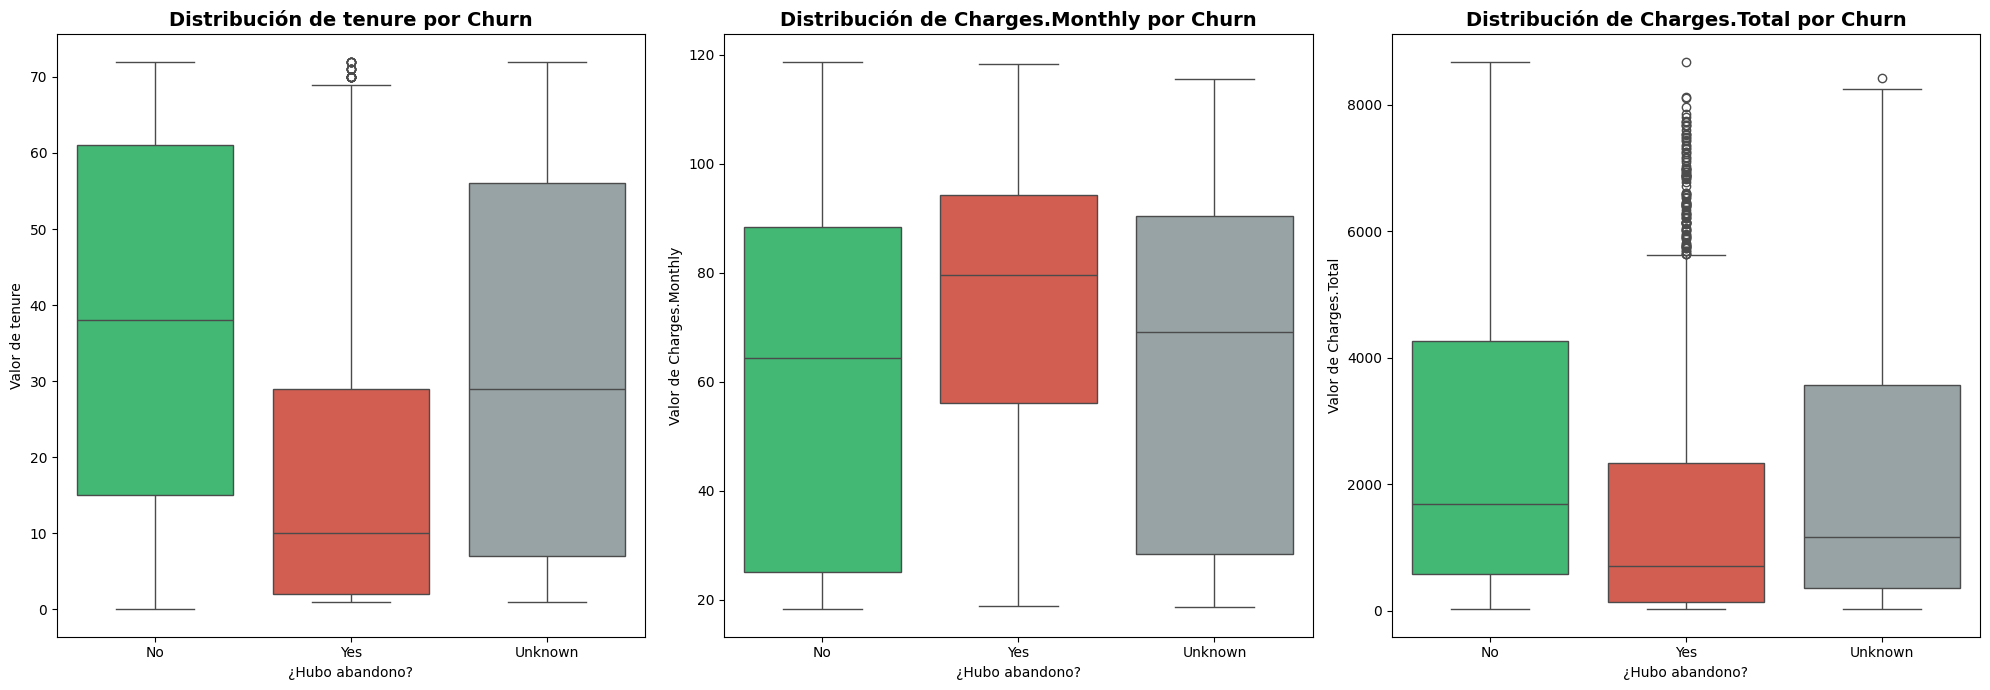

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=N_ROWS_NUM, ncols=N_COLS_NUM, figsize=(20, 7))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    if col in df_datos_v1.columns:

        sns.boxplot(x='Churn', y=col, data=df_datos_v1, ax=axes[i],
                    palette=COLORES_CHURN, order=['No', 'Yes', 'Unknown'])


        medianas = df_datos_v1.groupby('Churn')[col].median()

        axes[i].set_title(f'Distribución de {col} por Churn', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('¿Hubo abandono?')
        axes[i].set_ylabel(f'Valor de {col}')

plt.tight_layout()


plt.savefig('distribucion_numerica_churn.png', dpi=300, bbox_inches='tight')

plt.show()

#📄Informe final

# Informe "Análisis de Evasión de Clientes (Churn) - TelecomX LATAM"

## 🔹 1. Introducción

El presente informe detalla el análisis realizado sobre la base de datos de clientes de TelecomX LATAM. El objetivo principal de este proyecto es analizar y comprender el problema de evasión de clientes (Churn), es decir, la tasa a la que los clientes cancelan sus servicios.

Identificar los factores que impulsan a un cliente a abandonar la empresa es vital para la toma de decisiones estratégicas. A través de este análisis de datos, buscamos descubrir patrones de comportamiento y perfiles de riesgo que permitan a TelecomX LATAM diseñar campañas de retención proactivas y optimizar la satisfacción del cliente.

---

## 2. Limpieza y Tratamiento de Datos

Para garantizar la calidad del análisis, se procedió a realizar un riguroso proceso de extracción, transformación y limpieza (ETL) de los datos originales en formato JSON, el cual se detalla a continuación.

### 2.1. Proceso ETL

1. **Aplanamiento de Datos (Flattening):** Los datos anidados en el archivo JSON original fueron normalizados mediante `pd.json_normalize()` para extraer las subcategorías clave para el análisis: `customer`, `phone`, `internet` y `account`.

2. **Consolidación:** Se unificaron los distintos dataframes generados en el paso anterior, producto de la normalización de estos, en un único conjunto de datos consolidado (`df_datos_v1`) mediante la función `pd.concat()`.

3. **Limpieza de Nombres de Columnas:** Se eliminaron los prefijos generados por la normalización (ej. `customer.gender` a `gender`) para facilitar la escritura del código y la legibilidad de los gráficos.

4. **Tratamiento de Valores Nulos y Tipos de Datos:** Se identificaron y corrigieron inconsistencias, tales como reemplazo de puntos por coma, y reemplazdo de celdas vacías por valores nulos, lo cual asegura que las variables numéricas (como `Charges.Total` y `Charges.Monthly`) tengan el formato correcto (float) para su análisis estadístico. Además se estandarizó la variable objetivo `Churn` (identificando los estados 'No', 'Yes' y 'Unknown') con el objetico de no alterar los porcentajes de cada categoría pues el ultimo estado podría responder a que no se tiene certeza si procede a un abandono o no.

---

## 3. Análisis Exploratorio de Datos (EDA)

En este punto cabe destacar que se realizó un análisis visual exhaustivo para identificar qué variables categóricas y numéricas tienen mayor impacto en la decisión del cliente de abandonar la empresa.

Posterior a lo mencionado en el punto anterior, se procedio a graficar la proporcion general de abandonos, lo cual se aprecia en el siguiente gráfico.

![Tabla de Abandono](tabla_abandono.png)

![Distribución general de clientes](resumen_global_churn.png)
*Figura 1: Distribución general de clientes según su estado de permanencia.*
### Análisis de Variables Categóricas

Al evaluar la proporción de Churn en los distintos servicios y características demográficas, se destaca lo siguiente:

* **Contratos:** Los clientes con contratos de mes a mes (Month-to-month) presentan una tasa de evasión drásticamente mayor en comparación con aquellos que tienen contratos anuales o bianuales.

* **Servicios Adicionales:** La falta de servicios de valor agregado como Soporte Técnico (`TechSupport`), Seguridad en Línea (`OnlineSecurity`) y Respaldo (`OnlineBackup`) está fuertemente asociada con clientes que deciden irse.

* **Método de Pago:** Existe una concentración anómala de abandono en clientes que utilizan un método de pago específico (como el cheque electrónico).

![Análisis de Proporciones por Servicio](proporciones_categoricas_churn.png)
*Figura 2: Comparativa de riesgo de evasión por tipo de servicio y contrato.*

### Análisis de Variables Numéricas

Mediante diagramas de caja (Boxplots) y la funcion describe, analizamos el comportamiento del tiempo de permanencia y los costos:

![Estadísticas Descriptivas](tabla_stats_descriptivas.png)
*Figura 3: Resumen estadístico de las métricas principales.*

* **Tenure (Permanencia):** La mediana de permanencia de los clientes que abandonan es de apenas **10 meses**, mientras que los clientes leales superan los **38 meses**. La fuga es un problema de clientes nuevos.
* **Cargos Mensuales (`Charges.Monthly`):** Los clientes que se van tienden a tener facturas mensuales más altas (mediana cercana a los $80) que aquellos que se quedan (mediana de $65).

![Distribución de Gastos y Permanencia](distribucion_numerica_churn.png)
*Figura 4: Relación entre cargos mensuales, antigüedad del cliente y abandono.*

---

## 4. Conclusiones e Insights

A partir de los datos explorados, se puede deducir lo siguiente:

1. **El primer año es el periodo mas significativo:** La evasión ocurre mayoritariamente durante los primeros 12 meses de servicio. Si un cliente supera la barrera de los 2 a 3 años, la probabilidad de que se vaya disminuye significativamente.
2. **Sensibilidad al Precio vs. Valor Percibido:** Los clientes con altos cargos mensuales están abandonando la empresa. Sin embargo, esto permite inducir que la falta de servicios de soporte es un factor importante. Esto indica que los clientes no sienten que el servicio premium justifique su alto costo si no viene acompañado de seguridad y asistencia técnica.
3. **Inestabilidad del Contrato Mensual:** El modelo de pago mes a mes facilita la salida rápida del cliente ante la primera insatisfacción o mejor oferta de la competencia.
4. **Datos "Unknown":** Existe un segmento de la base de datos donde el estado de Churn es desconocido, el cual se comporta de manera intermedia y requiere una mejora en los sistemas de captura de datos de la empresa.

---

## 5. Recomendaciones Estratégicas

Para reducir la tasa de evasión (Churn) y aumentar el periodo que se mantiene el cliente, se sugieren las siguientes acciones:

* **Estrategia de Fidelización Temprana (Onboarding):** Implementar un programa de acompañamiento  durante los primeros 10 meses del cliente. Además de Ofrecer descuentos o beneficios temporales que los incentiven a llegar al segundo año de antigüedad.
* **Incentivar Contratos a Largo Plazo:** Crear ofertas significativas o reducciones parciales en la tarifa mensual a cambio de que los clientes de "mes a mes" migren a contratos de 1 o 2 años.
* **Empaquetado de Servicios :** Ofrecer servicios de *TechSupport* y *OnlineSecurity* de forma gratuita o a un costo marginal durante los primeros meses. Los datos demuestran que los clientes con estos servicios son mucho más leales.
* **Revisión de Métodos de Pago:** Investigar si los pagos mediante ciertos canales (como el cheque electrónico) presentan inconvenientes para el cliente y/o fallos que generen frustración y, por ende, la cancelación del servicio.



# Task
Extract the markdown content from the cell with ID `mxBDRHQSK71f` and save it to a new file named `README.md`.

## Extract Report Content

### Subtask:
Extract the markdown content from the 'Informe final' cell (cell ID mxBDRHQSK71f) which contains all the analysis and recommendations.


# Informe "Análisis de Evasión de Clientes (Churn) - TelecomX LATAM"

## 🔹 1. Introducción

El presente informe detalla el análisis realizado sobre la base de datos de clientes de TelecomX LATAM. El objetivo principal de este proyecto es analizar y comprender el problema de evasión de clientes (Churn), es decir, la tasa a la que los clientes cancelan sus servicios.

Identificar los factores que impulsan a un cliente a abandonar la empresa es vital para la toma de decisiones estratégicas. A través de este análisis de datos, buscamos descubrir patrones de comportamiento y perfiles de riesgo que permitan a TelecomX LATAM diseñar campañas de retención proactivas y optimizar la satisfacción del cliente.

---

## 2. Limpieza y Tratamiento de Datos

Para garantizar la calidad del análisis, se procedió a realizar un riguroso proceso de extracción, transformación y limpieza (ETL) de los datos originales en formato JSON, el cual se detalla a continuación.

### 2.1. Proceso ETL

1. **Aplanamiento de Datos (Flattening):** Los datos anidados en el archivo JSON original fueron normalizados mediante `pd.json_normalize()` para extraer las subcategorías clave para el análisis: `customer`, `phone`, `internet` y `account`.

2. **Consolidación:** Se unificaron los distintos dataframes generados en el paso anterior, producto de la normalización de estos, en un único conjunto de datos consolidado (`df_datos_v1`) mediante la función `pd.concat()`.

3. **Limpieza de Nombres de Columnas:** Se eliminaron los prefijos generados por la normalización (ej. `customer.gender` a `gender`) para facilitar la escritura del código y la legibilidad de los gráficos.

4. **Tratamiento de Valores Nulos y Tipos de Datos:** Se identificaron y corrigieron inconsistencias, tales como reemplazo de puntos por coma, y reemplazdo de celdas vacías por valores nulos, lo cual asegura que las variables numéricas (como `Charges.Total` y `Charges.Monthly`) tengan el formato correcto (float) para su análisis estadístico. Además se estandarizó la variable objetivo `Churn` (identificando los estados 'No', 'Yes' y 'Unknown') con el objetico de no alterar los porcentajes de cada categoría pues el ultimo estado podría responder a que no se tiene certeza si procede a un abandono o no.

---

## 3. Análisis Exploratorio de Datos (EDA)

En este punto cabe destacar que se realizó un análisis visual exhaustivo para identificar qué variables categóricas y numéricas tienen mayor impacto en la decisión del cliente de abandonar la empresa.

Posterior a lo mencionado en el punto anterior, se procedio a graficar la proporcion general de abandonos, lo cual se aprecia en el siguiente gráfico.

![Tabla de Abandono](tabla_abandono.png)

![Distribución general de clientes](resumen_global_churn.png)
*Figura 1: Distribución general de clientes según su estado de permanencia.*
### Análisis de Variables Categóricas

Al evaluar la proporción de Churn en los distintos servicios y características demográficas, se destaca lo siguiente:

* **Contratos:** Los clientes con contratos de mes a mes (Month-to-month) presentan una tasa de evasión drásticamente mayor en comparación con aquellos que tienen contratos anuales o bianuales.

* **Servicios Adicionales:** La falta de servicios de valor agregado como Soporte Técnico (`TechSupport`), Seguridad en Línea (`OnlineSecurity`) y Respaldo (`OnlineBackup`) está fuertemente asociada con clientes que deciden irse.

* **Método de Pago:** Existe una concentración anómala de abandono en clientes que utilizan un método de pago específico (como el cheque electrónico).

![Análisis de Proporciones por Servicio](proporciones_categoricas_churn.png)
*Figura 2: Comparativa de riesgo de evasión por tipo de servicio y contrato.*

### Análisis de Variables Numéricas

Mediante diagramas de caja (Boxplots) y la funcion describe, analizamos el comportamiento del tiempo de permanencia y los costos:

![Estadísticas Descriptivas](tabla_stats_descriptivas.png)
*Figura 3: Resumen estadístico de las métricas principales.*

* **Tenure (Permanencia):** La mediana de permanencia de los clientes que abandonan es de apenas **10 meses**, mientras que los clientes leales superan los **38 meses**. La fuga es un problema de clientes nuevos.
* **Cargos Mensuales (`Charges.Monthly`):** Los clientes que se van tienden a tener facturas mensuales más altas (mediana cercana a los $80) que aquellos que se quedan (mediana de $65).

![Distribución de Gastos y Permanencia](distribucion_numerica_churn.png)
*Figura 4: Relación entre cargos mensuales, antigüedad del cliente y abandono.*

---

## 4. Conclusiones e Insights

A partir de los datos explorados, se puede deducir lo siguiente:

1. **El primer año es el periodo mas significativo:** La evasión ocurre mayoritariamente durante los primeros 12 meses de servicio. Si un cliente supera la barrera de los 2 a 3 años, la probabilidad de que se vaya disminuye significativamente.
2. **Sensibilidad al Precio vs. Valor Percibido:** Los clientes con altos cargos mensuales están abandonando la empresa. Sin embargo, esto permite inducir que la falta de servicios de soporte es un factor importante. Esto indica que los clientes no sienten que el servicio premium justifique su alto costo si no viene acompañado de seguridad y asistencia técnica.
3. **Inestabilidad del Contrato Mensual:** El modelo de pago mes a mes facilita la salida rápida del cliente ante la primera insatisfacción o mejor oferta de la competencia.
4. **Datos "Unknown":** Existe un segmento de la base de datos donde el estado de Churn es desconocido, el cual se comporta de manera intermedia y requiere una mejora en los sistemas de captura de datos de la empresa.

---

## 5. Recomendaciones Estratégicas

Para reducir la tasa de evasión (Churn) y aumentar el periodo que se mantiene el cliente, se sugieren las siguientes acciones:

* **Estrategia de Fidelización Temprana (Onboarding):** Implementar un programa de acompañamiento  durante los primeros 10 meses del cliente. Además de Ofrecer descuentos o beneficios temporales que los incentiven a llegar al segundo año de antigüedad.
* **Incentivar Contratos a Largo Plazo:** Crear ofertas significativas o reducciones parciales en la tarifa mensual a cambio de que los clientes de "mes a mes" migren a contratos de 1 o 2 años.
* **Empaquetado de Servicios :** Ofrecer servicios de *TechSupport* y *OnlineSecurity* de forma gratuita o a un costo marginal durante los primeros meses. Los datos demuestran que los clientes con estos servicios son mucho más leales.
* **Revisión de Métodos de Pago:** Investigar si los pagos mediante ciertos canales (como el cheque electrónico) presentan inconvenientes para el cliente y/o fallos que generen frustración y, por ende, la cancelación del servicio.